## 1. Setup

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, confusion_matrix, roc_curve, auc,
    mean_absolute_error, r2_score, classification_report
)

from src.data import get_data
from src.data.features import return_all_features, make_transformer_sequences
from src.models.model_library import get_model

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# Consistent plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f8f8f8",
    "axes.grid":        True,
    "grid.alpha":       0.4,
    "font.size":        11,
})

TICKERS = [
    # Big Tech
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "TSLA", "NVDA", "ORCL", "INTC", "AMD",

    # Financials
    "JPM", "BAC", "WFC", "GS", "MS", "C", "AXP", "BLK", "SCHW", "COF",

    # Healthcare
    "JNJ", "UNH", "PFE", "ABBV", "MRK", "TMO", "ABT", "AMGN", "GILD", "CVS",

    # Consumer
    "WMT", "HD", "MCD", "SBUX", "NKE", "TGT", "COST", "LOW", "TJX", "BKNG",

    # Industrials
    "HON", "UPS", "CAT", "GE", "BA", "LMT", "RTX", "DE", "MMM", "EMR",

    # Energy
    "XOM", "CVX", "COP", "SLB", "OXY", "MPC", "PSX", "VLO", "HAL", "EOG",

    # Communications
    "T", "VZ", "TMUS", "CMCSA", "DIS", "NFLX", "V", "MA", "PYPL", "ADBE",
]

Device: cuda


## 2. Load data

In [2]:
data_train, data_test, data_val = get_data(
    TICKERS,
    "2012-01-01", "2026-01-01",
    split_date_val="2021-01-01",
    split_date_test="2023-01-01",
    feature_fn=return_all_features
)

print(f"Train samples : {len(data_train):,}")
print(f"Val samples   : {len(data_val):,}")
print(f"Test samples  : {len(data_test):,}")
print(f"Features      : {data_train.shape[1]} columns")

Train samples : 155,786
Val samples   : 33,740
Test samples  : 51,170
Features      : 30 columns


## 3. Classification models

We predict next-day direction: **1 = UP, 0 = DOWN**.

In [3]:
# Store results for comparison
clf_results = {}

X_train_feat = data_train.iloc[:, 0:7]
X_test_feat  = data_test.iloc[:, 0:7]
y_train_clf  = data_train.iloc[:, 7]
y_test_clf   = data_test.iloc[:, 7]

### 3.1 Logistic Regression

In [4]:
lr_model = get_model("logistic_regression")
lr_model.fit(X_train_feat, y_train_clf)

lr_pred  = lr_model.predict(X_test_feat)
lr_prob  = lr_model.predict_proba(X_test_feat)[:, 1]
lr_acc   = accuracy_score(y_test_clf, lr_pred)

clf_results["Logistic Regression"] = {"pred": lr_pred, "prob": lr_prob, "acc": lr_acc}
print(f"Logistic Regression — Test Accuracy: {lr_acc:.4f}")

Logistic Regression — Test Accuracy: 0.5329


### 3.2 Random Forest

In [5]:
rf_model = get_model("random_forest")
rf_model.fit(X_train_feat, y_train_clf)

rf_pred  = rf_model.predict(X_test_feat)
rf_prob  = rf_model.predict_proba(X_test_feat)[:, 1]
rf_acc   = accuracy_score(y_test_clf, rf_pred)

clf_results["Random Forest"] = {"pred": rf_pred, "prob": rf_prob, "acc": rf_acc}
print(f"Random Forest — Test Accuracy: {rf_acc:.4f}")

Random Forest — Test Accuracy: 0.5158


### 3.3 SVM

In [6]:
svm_model = get_model("svm")
svm_model.fit(X_train_feat, y_train_clf)

svm_pred  = svm_model.predict(X_test_feat)
svm_prob  = svm_model.predict_proba(X_test_feat)[:, 1]
svm_acc   = accuracy_score(y_test_clf, svm_pred)

clf_results["SVM"] = {"pred": svm_pred, "prob": svm_prob, "acc": svm_acc}
print(f"SVM — Test Accuracy: {svm_acc:.4f}")

SVM — Test Accuracy: 0.5327


### 3.4 XGBoost

In [7]:
xgb_model = get_model("xgboost")
xgb_model.fit(X_train_feat, y_train_clf)

xgb_pred  = xgb_model.predict(X_test_feat)
xgb_prob  = xgb_model.predict_proba(X_test_feat)[:, 1]
xgb_acc   = accuracy_score(y_test_clf, xgb_pred)

clf_results["XGBoost"] = {"pred": xgb_pred, "prob": xgb_prob, "acc": xgb_acc}
print(f"XGBoost — Test Accuracy: {xgb_acc:.4f}")

XGBoost — Test Accuracy: 0.5295


### 3.5 Hybrid CNN + Features

In [8]:
hybrid_clf = get_model(
    "hybrid",
    signal_length=data_train.iloc[:, 9:].shape[1],
    n_handcrafted=data_train.iloc[:, 0:7].shape[1]
).to(device)

history_clf = hybrid_clf.fit(
    data_train.iloc[:, 9:-1].to_numpy(), data_train.iloc[:, 0:7].to_numpy(), data_train.iloc[:, 7].to_numpy(),
    data_val.iloc[:, 9:-1].to_numpy(),   data_val.iloc[:, 0:7].to_numpy(),   data_val.iloc[:, 7].to_numpy(),
    batch_size=64, epochs=8
)

hybrid_pred, hybrid_prob = hybrid_clf.evaluate(
    data_test.iloc[:, 9:-1].to_numpy(),
    data_test.iloc[:, 0:7].to_numpy()
)
hybrid_acc = accuracy_score(data_test.iloc[:, 7].to_numpy(), hybrid_pred)

clf_results["Hybrid CNN"] = {"pred": hybrid_pred, "prob": hybrid_prob, "acc": hybrid_acc}
print(f"Hybrid CNN — Test Accuracy: {hybrid_acc:.4f}")

Epoch   1/8 | Train loss: 0.6646  acc: 0.591 | Val loss: 0.6462  acc: 0.620
Epoch   2/8 | Train loss: 0.6492  acc: 0.613 | Val loss: 0.6482  acc: 0.612
Epoch   3/8 | Train loss: 0.6432  acc: 0.621 | Val loss: 0.6360  acc: 0.634
Epoch   4/8 | Train loss: 0.6394  acc: 0.626 | Val loss: 0.6325  acc: 0.640
Epoch   5/8 | Train loss: 0.6364  acc: 0.632 | Val loss: 0.6306  acc: 0.640
Epoch   6/8 | Train loss: 0.6336  acc: 0.634 | Val loss: 0.6347  acc: 0.634
Epoch   7/8 | Train loss: 0.6323  acc: 0.636 | Val loss: 0.6326  acc: 0.638


2026/05/24 22:55:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch   8/8 | Train loss: 0.6306  acc: 0.637 | Val loss: 0.6276  acc: 0.642


2026/05/24 22:55:19 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/24 22:55:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/24 22:55:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Hybrid CNN — Test Accuracy: 0.6294


### 3.6 Hybrid CNN — Training curves

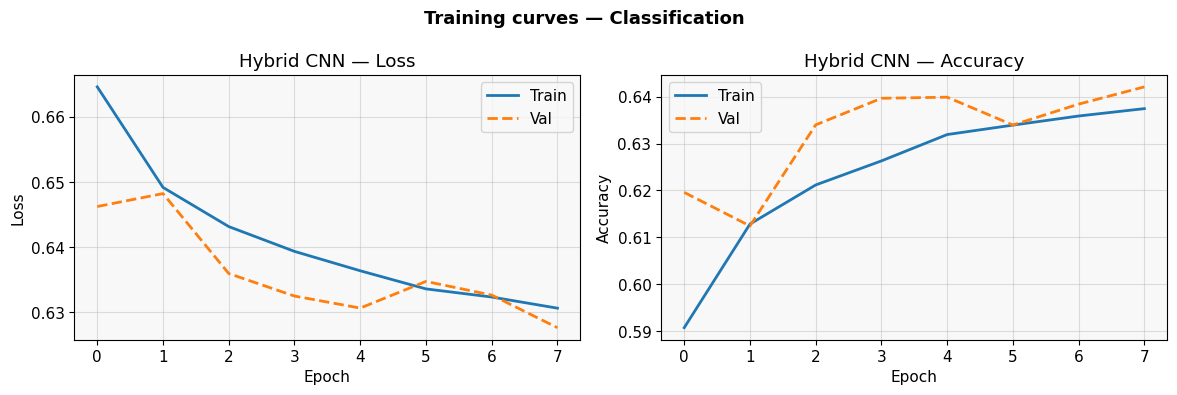

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history_clf["train_loss"], label="Train", linewidth=2)
axes[0].plot(history_clf["val_loss"],   label="Val",   linewidth=2, linestyle="--")
axes[0].set_title("Hybrid CNN — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history_clf["train_acc"], label="Train", linewidth=2)
axes[1].plot(history_clf["val_acc"],   label="Val",   linewidth=2, linestyle="--")
axes[1].set_title("Hybrid CNN — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Training curves — Classification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.8 Transformer classifier

In [10]:
X_train_seq = make_transformer_sequences(data_train, 30)
X_val_seq   = make_transformer_sequences(data_val,   30)
X_test_seq  = make_transformer_sequences(data_test,  30)

print(f"Train sequences : {X_train_seq.shape}")
print(f"Val sequences   : {X_val_seq.shape}")
print(f"Test sequences  : {X_test_seq.shape}")
print(f"Signal slice    : {X_train_seq[:, :, 9:].shape}")

Train sequences : (5138, 30, 29)
Val sequences   : (1120, 30, 29)
Test sequences  : (1680, 30, 29)
Signal slice    : (5138, 30, 20)


In [11]:
transformer_clf = get_model(
    "transformer",
    n_features = 7,
    seq_len    = 30,
    signal_len = 20,
    d_model    = 32,
    n_heads    = 2,
    n_layers   = 3,
    dropout    = 0.3,
).to(device)

history_transformer = transformer_clf.fit(
    X_train_seq[:, :, 9:], X_train_seq[:, :, 0:7], X_train_seq[:, -1, 7],
    X_val_seq[:, :, 9:],   X_val_seq[:, :, 0:7],   X_val_seq[:, -1, 7],
    epochs=12
)

transformer_pred, transformer_prob = transformer_clf.evaluate(
    X_test_seq[:, :, 9:],
    X_test_seq[:, :, 0:7]
)

y_test_transformer = X_test_seq[:, -1, 7]
transformer_acc = accuracy_score(y_test_transformer, transformer_pred)

clf_results["Transformer"] = {"pred": transformer_pred, "prob": transformer_prob, "acc": transformer_acc}
print(f"Transformer — Test Accuracy: {transformer_acc:.4f}")

Starting Training Loop
Epoch  Train Loss  Train Acc  Val Loss   Val Acc
-------------------------------------------------------


c:\Users\logan\PycharmProjects\PsychicLamp\venv\lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


    1      0.6975      0.498    0.6954     0.489
    2      0.6967      0.496    0.6925     0.546
    3      0.6965      0.501    0.6941     0.532
    4      0.6934      0.505    0.6954     0.505
    5      0.6912      0.530    0.6960     0.507
    6      0.6948      0.509    0.6943     0.520
    7      0.6924      0.510    0.6949     0.518
    8      0.6934      0.512    0.6945     0.520
    9      0.6941      0.498    0.6943     0.537
   10      0.6926      0.508    0.6941     0.530
   11      0.6935      0.512    0.6941     0.537


2026/05/24 22:56:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


   12      0.6916      0.512    0.6941     0.535


2026/05/24 22:56:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/24 22:56:27 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/24 22:56:27 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


Run ID: 5c749c715a4548f0aa9925c71ff49bb9
Artifact URI: file:///C:/Users/logan/PycharmProjects/stockforecast/stock-forecast-ml/mlruns/0/5c749c715a4548f0aa9925c71ff49bb9/artifacts
Transformer — Test Accuracy: 0.5220


### 3.9 Transformer — Training curves

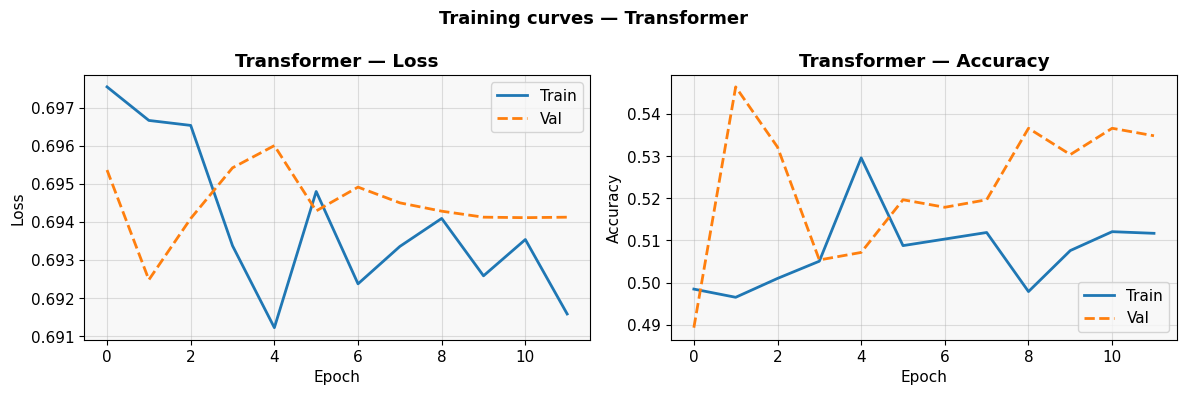

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_transformer["train_loss"], label="Train", linewidth=2)
axes[0].plot(history_transformer["val_loss"],   label="Val",   linewidth=2, linestyle="--")
axes[0].set_title("Transformer — Loss", fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_transformer["train_acc"], label="Train", linewidth=2)
axes[1].plot(history_transformer["val_acc"],   label="Val",   linewidth=2, linestyle="--")
axes[1].set_title("Transformer — Accuracy", fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.suptitle("Training curves — Transformer", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.10 All classifiers — comparison plots

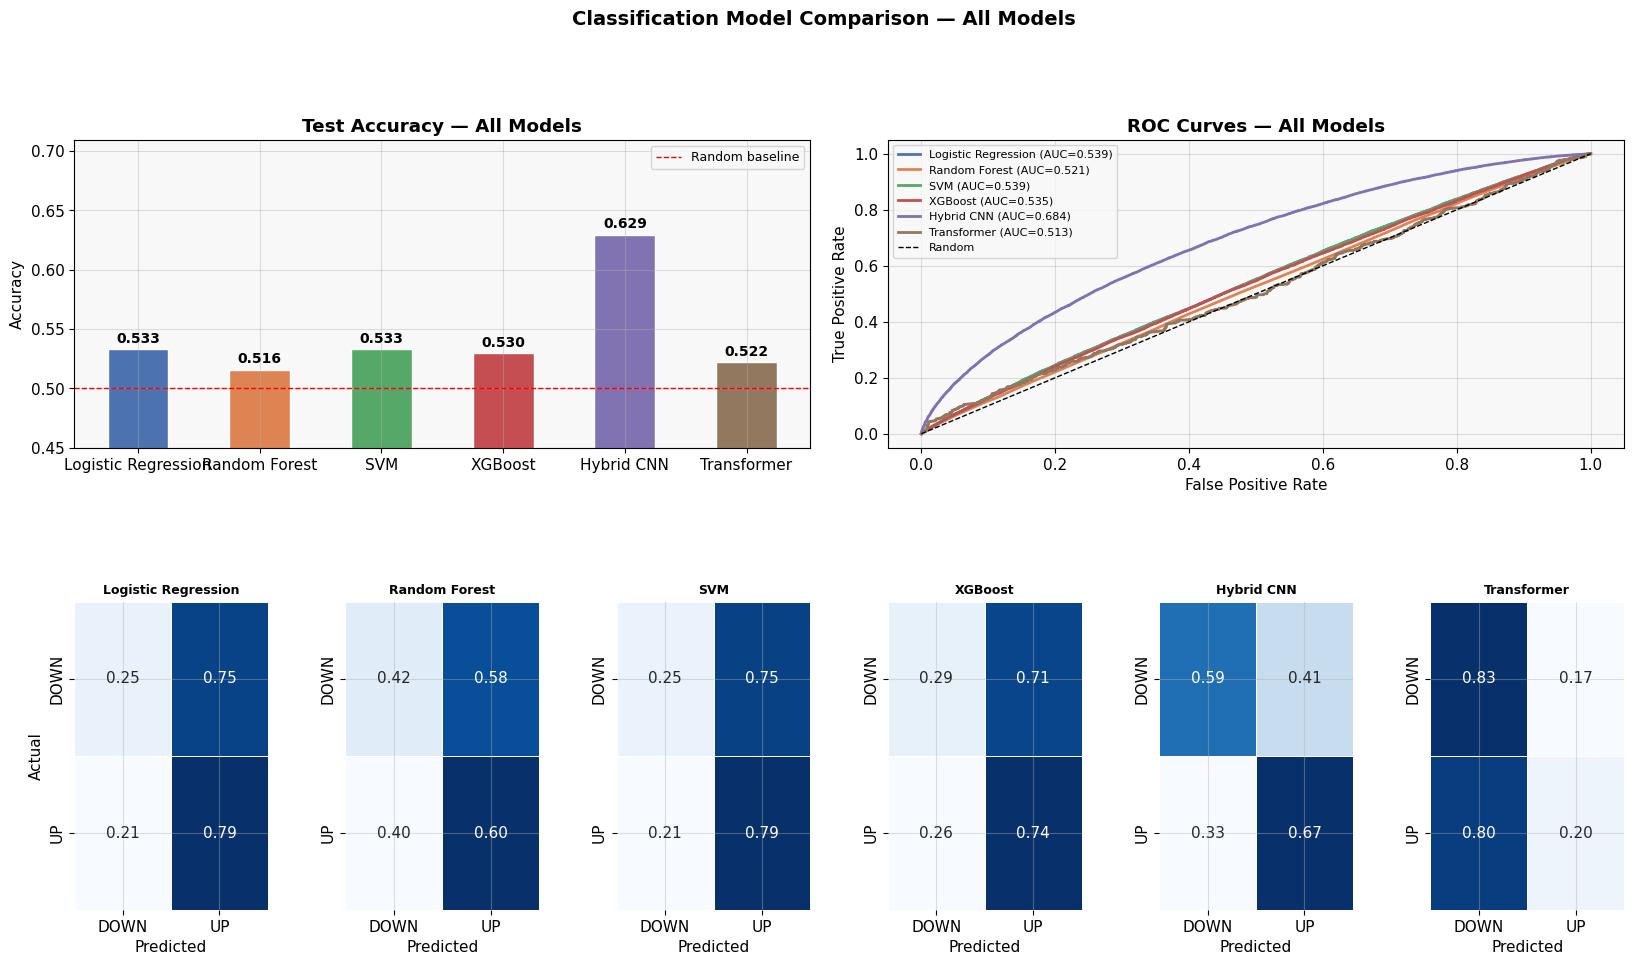

In [13]:
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig = plt.figure(figsize=(20, 10))
gs  = gridspec.GridSpec(2, len(clf_results), figure=fig, hspace=0.5, wspace=0.4)

# ── Accuracy bar chart ──────────────────────────────────────────────────────
ax_acc = fig.add_subplot(gs[0, :3])
names  = list(clf_results.keys())
accs   = [clf_results[n]["acc"] for n in names]
bars   = ax_acc.bar(names, accs, color=colors[:len(names)], width=0.5, edgecolor="white")
ax_acc.axhline(0.5, color="red", linewidth=1, linestyle="--", label="Random baseline")
ax_acc.set_ylim(0.45, min(max(accs) + 0.08, 1.0))
ax_acc.set_title("Test Accuracy — All Models", fontweight="bold")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend(fontsize=9)
for bar, acc in zip(bars, accs):
    ax_acc.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{acc:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

# ── ROC curves ──────────────────────────────────────────────────────────────
ax_roc = fig.add_subplot(gs[0, 3:])
for (name, res), color in zip(clf_results.items(), colors):
    y_true = y_test_transformer if name == "Transformer" else y_test_clf
    fpr, tpr, _ = roc_curve(y_true, res["prob"])
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC={roc_auc:.3f})")
ax_roc.plot([0,1],[0,1], "k--", linewidth=1, label="Random")
ax_roc.set_title("ROC Curves — All Models", fontweight="bold")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(fontsize=8)

# ── Confusion matrices ──────────────────────────────────────────────────────
for idx, (name, res) in enumerate(clf_results.items()):
    ax = fig.add_subplot(gs[1, idx])
    y_true = y_test_transformer if name == "Transformer" else y_test_clf
    cm = confusion_matrix(y_true, res["pred"], normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=["DOWN","UP"], yticklabels=["DOWN","UP"],
                cbar=False, linewidths=0.5)
    ax.set_title(name, fontweight="bold", fontsize=9)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual" if idx == 0 else "")

plt.suptitle("Classification Model Comparison — All Models", fontsize=14, fontweight="bold", y=1.01)
plt.show()

### 3.11 Classification report — best model

In [14]:
best_name = max(clf_results, key=lambda n: clf_results[n]["acc"])
best_pred = clf_results[best_name]["pred"]
y_true_best = y_test_transformer if best_name == "Transformer" else y_test_clf

print(f"Best model: {best_name} ({clf_results[best_name]['acc']:.4f} accuracy)\n")
print(classification_report(y_true_best, best_pred, target_names=["DOWN", "UP"]))

Best model: Hybrid CNN (0.6294 accuracy)

              precision    recall  f1-score   support

        DOWN       0.62      0.59      0.60     24448
          UP       0.64      0.67      0.65     26722

    accuracy                           0.63     51170
   macro avg       0.63      0.63      0.63     51170
weighted avg       0.63      0.63      0.63     51170



## 4. Regression model

We predict next-day **daily % return** as a continuous value.

### 4.1 Train Hybrid CNN — Regression

In [15]:
hybrid_reg = get_model(
    "hybrid",
    signal_length=data_train.iloc[:, 9:].shape[1],
    n_handcrafted=data_train.iloc[:, 0:7].shape[1],
    task="regression"
).to(device)

history_reg = hybrid_reg.fit(
    data_train.iloc[:, 9:-1].to_numpy(), data_train.iloc[:, 0:7].to_numpy(), data_train.iloc[:, 8].to_numpy(),
    data_val.iloc[:, 9:-1].to_numpy(),   data_val.iloc[:, 0:7].to_numpy(),   data_val.iloc[:, 8].to_numpy(),
    batch_size=64, epochs=8
)

reg_pred_test  = hybrid_reg.evaluate(data_test.iloc[:, 9:-1].to_numpy(),  data_test.iloc[:, 0:7].to_numpy())
reg_pred_train = hybrid_reg.evaluate(data_train.iloc[:, 9:-1].to_numpy(), data_train.iloc[:, 0:7].to_numpy())

y_test_reg  = data_test.iloc[:, 8].to_numpy()
y_train_reg = data_train.iloc[:, 8].to_numpy()

mae      = mean_absolute_error(y_test_reg, reg_pred_test)
r2_test  = r2_score(y_test_reg, reg_pred_test)
r2_train = r2_score(y_train_reg, reg_pred_train)

print(f"MAE        : {mae:.4f}")
print(f"R² (test)  : {r2_test:.4f}")
print(f"R² (train) : {r2_train:.4f}")
if r2_train - r2_test > 0.1:
    print("\nLarge train/test R² gap — model may be overfitting")

Epoch   1/8 | Train loss: 0.0004  acc: 0.000 | Val loss: 0.0004  acc: 0.000
Epoch   2/8 | Train loss: 0.0003  acc: 0.000 | Val loss: 0.0004  acc: 0.000
Epoch   3/8 | Train loss: 0.0003  acc: 0.000 | Val loss: 0.0004  acc: 0.000
Epoch   4/8 | Train loss: 0.0003  acc: 0.000 | Val loss: 0.0004  acc: 0.000
Epoch   5/8 | Train loss: 0.0003  acc: 0.000 | Val loss: 0.0004  acc: 0.000
Epoch   6/8 | Train loss: 0.0003  acc: 0.000 | Val loss: 0.0004  acc: 0.000
Epoch   7/8 | Train loss: 0.0003  acc: 0.000 | Val loss: 0.0004  acc: 0.000


2026/05/24 22:58:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch   8/8 | Train loss: 0.0003  acc: 0.000 | Val loss: 0.0004  acc: 0.000


2026/05/24 22:58:13 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/24 22:58:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.5.1+cu121) contains a local version label (+cu121). MLflow logged a pip requirement for this package as 'torch==2.5.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/24 22:58:20 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


MAE        : 0.0119
R² (test)  : 0.1149
R² (train) : 0.2141


### 4.2 Regression — Training curves

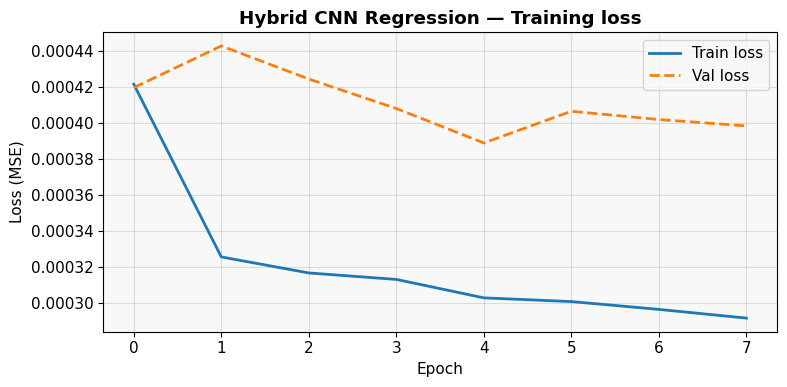

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_reg["train_loss"], label="Train loss", linewidth=2)
ax.plot(history_reg["val_loss"],   label="Val loss",   linewidth=2, linestyle="--")
ax.set_title("Hybrid CNN Regression — Training loss", fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (MSE)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Regression — Prediction plots

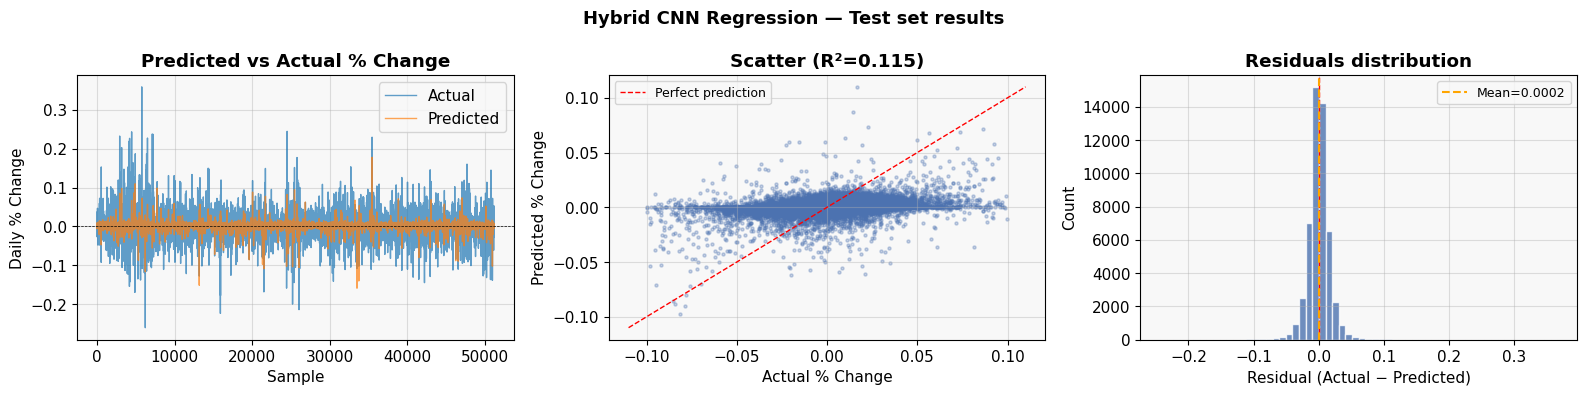


Outliers (|actual| > 10%): 151
Outlier actual values: [ 0.1533  0.1013  0.1022  0.1198  0.2328  0.1393  0.2032 -0.1056  0.1476
  0.1125 -0.1133  0.1009 -0.1213  0.1206  0.1531  0.102  -0.1233  0.2192
  0.1475 -0.1543  0.1193 -0.1042  0.2269 -0.1426  0.1402  0.2437  0.164
 -0.1     0.1281 -0.1697  0.1872 -0.135  -0.1244  0.1175  0.1332  0.1144
 -0.1379  0.122   0.1331  0.3595 -0.1083 -0.1191 -0.2606  0.1606  0.146
 -0.115   0.1875  0.2277  0.1019  0.1116  0.1069 -0.1021 -0.1062  0.2382
  0.2371  0.1137  0.1154 -0.1106  0.1311  0.131   0.1182  0.1161  0.1135
 -0.1214  0.1338 -0.1277 -0.1169 -0.1157  0.1257 -0.1018  0.1501  0.1481
 -0.2238 -0.1779 -0.1093  0.1198 -0.1257  0.1182 -0.1015 -0.1684  0.1133
  0.1495 -0.1588  0.245  -0.1122  0.1128 -0.1183 -0.1998 -0.1444  0.1136
  0.1519 -0.1054  0.1775  0.1202  0.112  -0.2141 -0.1086  0.1006 -0.1015
  0.1086 -0.1205 -0.1411 -0.1057  0.1163 -0.111   0.1057 -0.1047  0.1537
  0.1015 -0.1081 -0.1022 -0.1103  0.2299  0.1043  0.1092 -0.1023  0.107

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── Predicted vs Actual over time ───────────────────────────────────────────
axes[0].plot(y_test_reg,      label="Actual",    alpha=0.7, linewidth=1)
axes[0].plot(reg_pred_test,   label="Predicted", alpha=0.7, linewidth=1)
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_title("Predicted vs Actual % Change", fontweight="bold")
axes[0].set_xlabel("Sample")
axes[0].set_ylabel("Daily % Change")
axes[0].legend()

# ── Scatter: Predicted vs Actual ────────────────────────────────────────────
# Remove outliers for cleaner plot
mask = np.abs(y_test_reg) < 0.10
axes[1].scatter(y_test_reg[mask], reg_pred_test[mask], alpha=0.3, s=5, color="#4C72B0")
lim = max(np.abs(y_test_reg[mask]).max(), np.abs(reg_pred_test[mask]).max())
axes[1].plot([-lim, lim], [-lim, lim], "r--", linewidth=1, label="Perfect prediction")
axes[1].set_title(f"Scatter (R²={r2_test:.3f})", fontweight="bold")
axes[1].set_xlabel("Actual % Change")
axes[1].set_ylabel("Predicted % Change")
axes[1].legend(fontsize=9)

# ── Residuals distribution ───────────────────────────────────────────────────
residuals = y_test_reg - reg_pred_test
axes[2].hist(residuals, bins=60, color="#4C72B0", edgecolor="white", alpha=0.8)
axes[2].axvline(0, color="red", linewidth=1, linestyle="--")
axes[2].axvline(residuals.mean(), color="orange", linewidth=1.5, linestyle="--",
                label=f"Mean={residuals.mean():.4f}")
axes[2].set_title("Residuals distribution", fontweight="bold")
axes[2].set_xlabel("Residual (Actual − Predicted)")
axes[2].set_ylabel("Count")
axes[2].legend(fontsize=9)

plt.suptitle("Hybrid CNN Regression — Test set results", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Outlier report
outlier_idx = np.where(np.abs(y_test_reg) > 0.10)[0]
print(f"\nOutliers (|actual| > 10%): {len(outlier_idx)}")
if len(outlier_idx) > 0:
    print(f"Outlier actual values: {y_test_reg[outlier_idx].round(4)}")

## 5. Summary

In [18]:
print("=" * 55)
print("CLASSIFICATION RESULTS")
print("=" * 55)
for name, res in sorted(clf_results.items(), key=lambda x: -x[1]["acc"]):
    y_true = y_test_transformer if name == "Transformer" else y_test_clf
    fpr, tpr, _ = roc_curve(y_true, res["prob"])
    roc_auc = auc(fpr, tpr)
    print(f"  {name:<25} Accuracy={res['acc']:.4f}   AUC={roc_auc:.4f}")

print()
print("=" * 50)
print("REGRESSION RESULTS — Hybrid CNN")
print("=" * 50)
print(f"  MAE            : {mae:.4f}")
print(f"  R² (test)      : {r2_test:.4f}")
print(f"  R² (train)     : {r2_train:.4f}")
print(f"  Overfit gap    : {r2_train - r2_test:.4f}")

CLASSIFICATION RESULTS
  Hybrid CNN                Accuracy=0.6294   AUC=0.6845
  Logistic Regression       Accuracy=0.5329   AUC=0.5392
  SVM                       Accuracy=0.5327   AUC=0.5392
  XGBoost                   Accuracy=0.5295   AUC=0.5354
  Transformer               Accuracy=0.5220   AUC=0.5133
  Random Forest             Accuracy=0.5158   AUC=0.5208

REGRESSION RESULTS — Hybrid CNN
  MAE            : 0.0119
  R² (test)      : 0.1149
  R² (train)     : 0.2141
  Overfit gap    : 0.0993
